In [1]:
import os
import re
import json
import gc

import numpy as np
import pandas as pd
from tqdm import tqdm

gc.collect()

0

### **Train - Test - Split**

In [8]:
# Load encoded data without pocket sequences
drop_cols = ["protein_sequences", "pocket_sequences", "ligand_smiles"]

df_all_encoded = pd.read_csv(
    "PDBbind_protein_pocket_ligands_bindingsites_encoded.csv",)
df_all_encoded = df_all_encoded.drop(columns=drop_cols)
df_all_encoded = df_all_encoded.dropna().reset_index(drop=True)

# Load OOD_splits json and split into train and test sets
ood_splits_path = r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_ood_splits"
split_files = [f for f in os.listdir(ood_splits_path) if f.endswith(".json")]

# Dictionary to hold the splits
train_datasets, test_datasets = {}, {}

# Iterate over all JSON files in the directory
for file in split_files:
    split_name = file.split("_")[1]  # e.g. "1nvq"
    with open(os.path.join(ood_splits_path, file), "r") as f:
        split = json.load(f)

    # Split train/test
    train_df = df_all_encoded[df_all_encoded["pdb_id"].isin(split["train"])]
    test_ids = {pdb for k, v in split.items() if k != "train" for pdb in v}
    test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(test_ids)]

    # Features & Labels
    X_train, y_train = train_df.drop(columns=["pK", "pdb_id"]), train_df["pK"]
    X_test, y_test = test_df.drop(columns=["pK", "pdb_id"]), test_df["pK"]

    # Store in dicts
    train_datasets[split_name] = (X_train, y_train)
    test_datasets[split_name] = (X_test, y_test)

print(f"Loaded {len(train_datasets)} dataset splits:")
for name, (Xtr, _) in train_datasets.items():
    print(f" - {name}: {len(Xtr)} train / {len(test_datasets[name][0])} test samples")

Loaded 7 dataset splits:
 - 1nvq: 27505 train / 5343 test samples
 - 1sqa: 31141 train / 1461 test samples
 - 2p15: 31568 train / 920 test samples
 - 2vw5: 32076 train / 412 test samples
 - 3dd0: 31606 train / 939 test samples
 - 3f3e: 31691 train / 781 test samples
 - 3o9i: 31808 train / 908 test samples


In [10]:
X_train_1nvq, y_train_1nvq = train_datasets["1nvq"]
X_test_1nvq, y_test_1nvq = test_datasets["1nvq"]

X_train_1sqa, y_train_1sqa = train_datasets["1sqa"]
X_test_1sqa, y_test_1sqa = test_datasets["1sqa"]

X_train_2p15, y_train_2p15 = train_datasets["2p15"]
X_test_2p15, y_test_2p15 = test_datasets["2p15"]

X_train_2vw5, y_train_2vw5 = train_datasets["2vw5"]
X_test_2vw5, y_test_2vw5 = test_datasets["2vw5"]

X_train_3dd0, y_train_3dd0 = train_datasets["3dd0"]
X_test_3dd0, y_test_3dd0 = test_datasets["3dd0"]

X_train_3f3e, y_train_3f3e = train_datasets["3f3e"]
X_test_3f3e, y_test_3f3e = test_datasets["3f3e"]

X_train_3o9i, y_train_3o9i = train_datasets["3o9i"]
X_test_3o9i, y_test_3o9i = test_datasets["3o9i"]

### **Model selection & training**

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

#### **Regression**

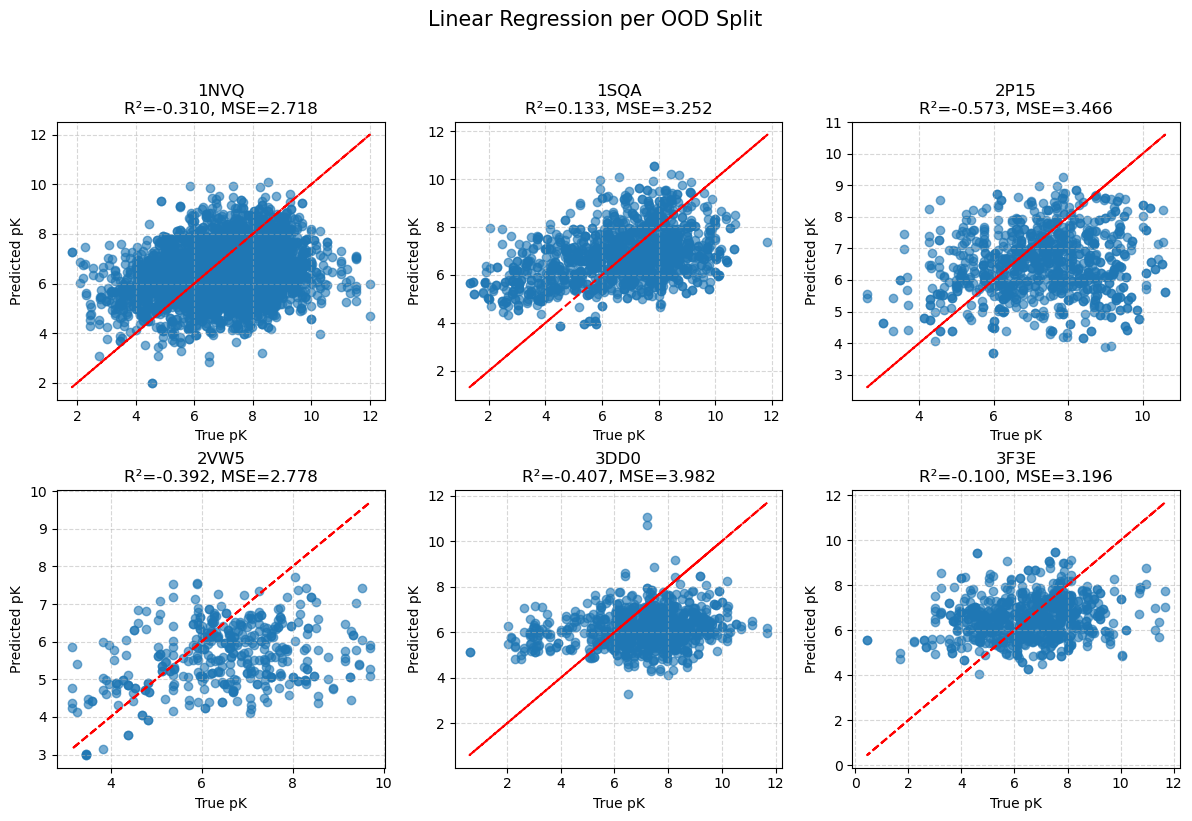

In [13]:
# Train and evaluate Linear Regression for each split
results = {}
for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = {"R²": r2, "MSE": mse}

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    model = LinearRegression()
    model.fit(*train_datasets[name])
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot(y_test, y_test, color="red", linestyle="--")
    ax.set_title(f"{name.upper()}\nR²={results[name]['R²']:.3f}, MSE={results[name]['MSE']:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle("Linear Regression per OOD Split", fontsize=15, y=1.02)
plt.show()

#### **HistGradientBoosting Regression**

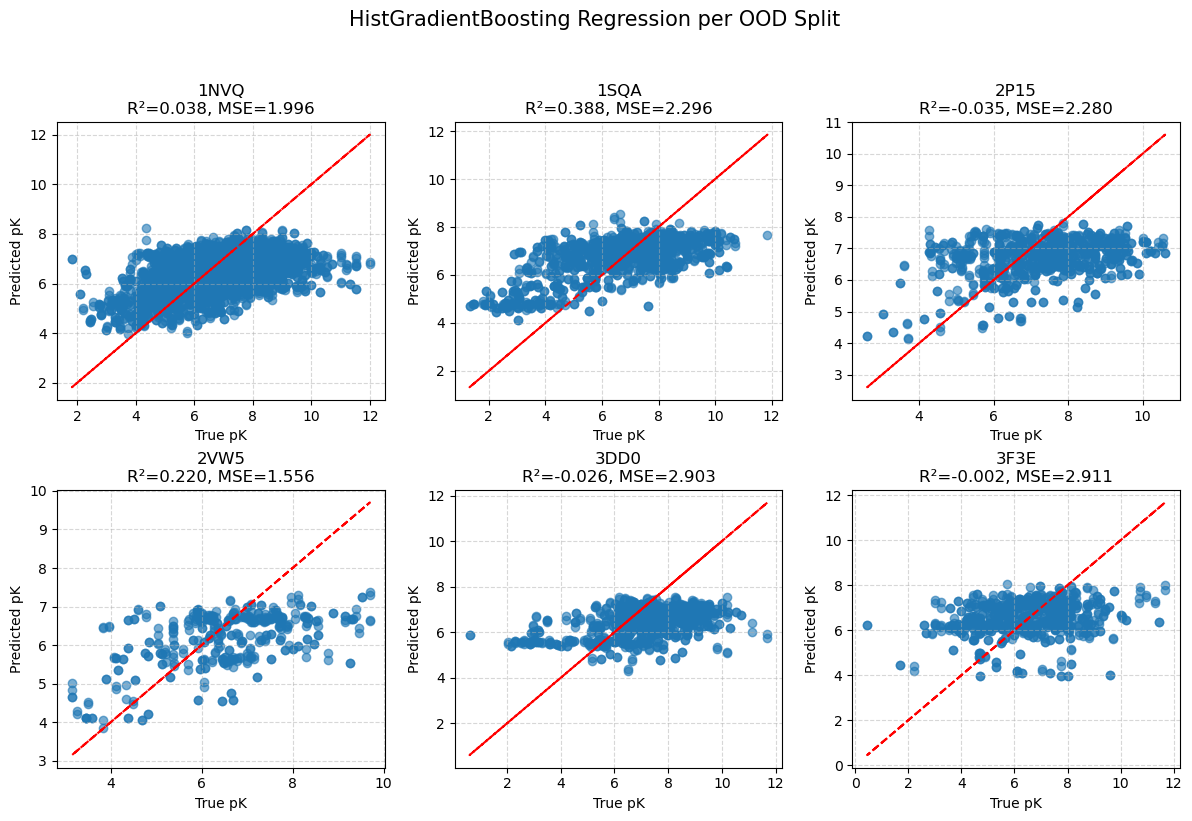

In [14]:
# Train and evaluate HistGradientBoosting for each split
results_hgb = {}
for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    model = HistGradientBoostingRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results_hgb[name] = {"R²": r2, "MSE": mse}

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    model = HistGradientBoostingRegressor(random_state=42)
    model.fit(*train_datasets[name])
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot(y_test, y_test, color="red", linestyle="--")
    ax.set_title(f"{name.upper()}\nR²={results_hgb[name]['R²']:.3f}, MSE={results_hgb[name]['MSE']:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle("HistGradientBoosting Regression per OOD Split", fontsize=15, y=1.02)
plt.show()

#### **XGBoost**

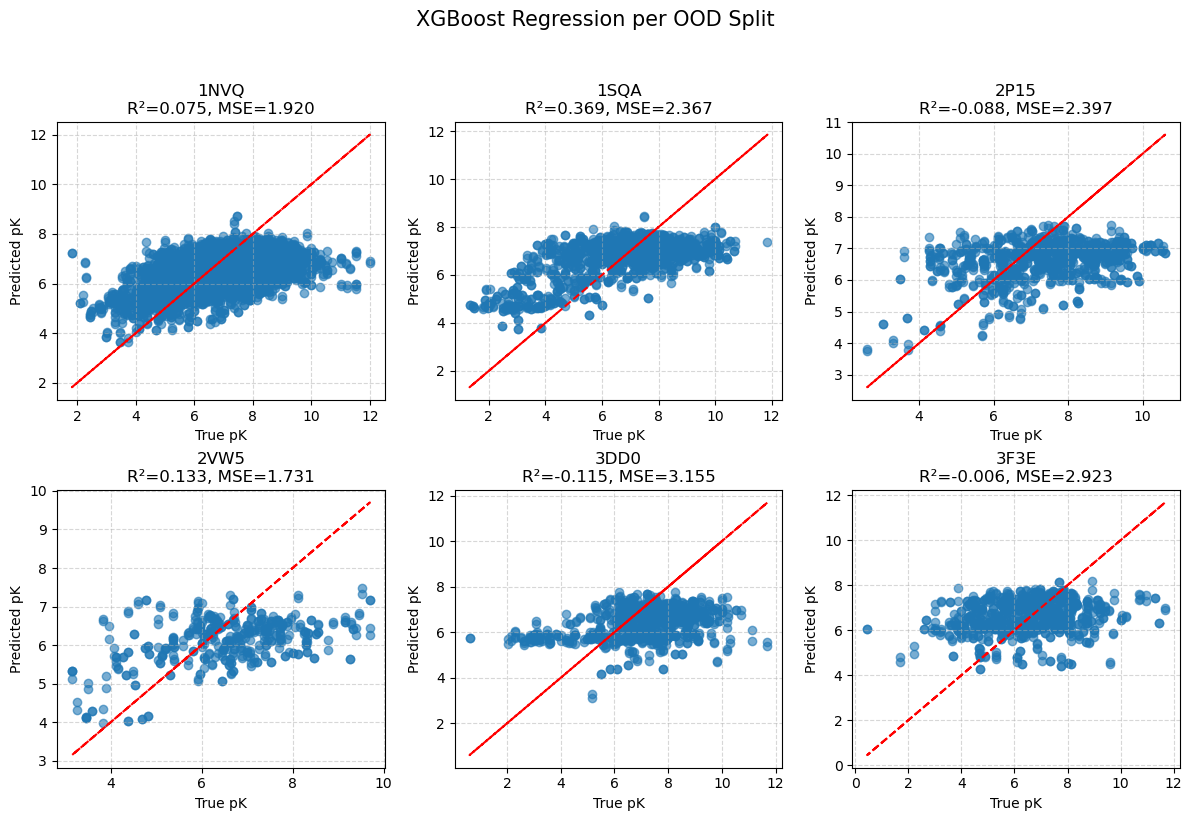

In [17]:
# XGBoost parameters
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "device": "cuda",   # GPU 
    "seed": 42
}

results_xgb = {}

# Train and evaluate XGBoost per dataset
for name, (X_train, y_train) in train_datasets.items():
    X_test, y_test = test_datasets[name]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    model = xgb.train(params, dtrain, num_boost_round=500)

    y_pred = model.predict(dtest)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results_xgb[name] = {"R²": r2, "MSE": mse}

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    dtrain = xgb.DMatrix(*train_datasets[name])
    dtest = xgb.DMatrix(X_test, label=y_test)

    model = xgb.train(params, dtrain, num_boost_round=500)
    y_pred = model.predict(dtest)

    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot(y_test, y_test, color="red", linestyle="--")
    ax.set_title(f"{name.upper()}\nR²={results_xgb[name]['R²']:.3f}, MSE={results_xgb[name]['MSE']:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle("XGBoost Regression per OOD Split", fontsize=15, y=1.02)
plt.show()

| R² Value  | Meaning                                                                       |
| :-------- | :---------------------------------------------------------------------------- |
| **1.0**   | Perfect prediction        |
| **0.0**   | The model is no better than simply predicting the mean of the target variable |
| **< 0.0** | The model performs worse than predicting the mean                             |
